# PERTEMUAN 2
# MODUL 3 - FEATURE ENGINEERING & EDA

Cakupan Pembelajaran:

**Data Mentah/Raw -> Feature Engineering -> Feature Selection -> EDA -> Visualisasi -> Insight**

Dataset: **Penguins** dari Seaborn

## Tujuan

- memahami konsep **Feature Engineering** dan **EDA**;
- menerapkan encoding pada data kategorikal;
- melakukan **binning** pada fitur numerik;
- menggunakan korelasi untuk feature selection dasar;
- membuat dan membaca Histogram, Box Plot, Violin Plot, dan Scatter Plot.

## 1. Feature Engineering & EDA

**Feature Engineering**: Proses mengubah data mentah menjadi fitur yang lebih informatif dan sesuai untuk analisis/model.

Seperti **menyiapkan bahan masakan**, bahan mentah perlu dipotong atau dikelompokkan sebelum digunakan.

**EDA (Exploratory Data Analysis)**: Proses menyelidiki data untuk menemukan pola, anomali, dan karakteristik data melalui statistik serta visualisasi.

Hubungan antara Feature Engineering dan EDA:

**EDA -> menemukan pola -> Feature Engineering -> EDA kembali**

## 2. Persiapan Library

Library yang digunakan:
- `Pandas` -> pengolahan data
- `Seaborn` -> dataset dan visualisasi
- `Matplotlib` -> visualisasi
- `Scikit-learn` -> encoding

In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import OrdinalEncoder, LabelEncoder

## 3. Mengenal Dataset Penguins

Beberapa kolom penting:
- `species` -> spesies pinguin
- `island` -> pulau
- `bill_length_mm` -> panjang paruh
- `bill_depth_mm` -> kedalaman paruh
- `flipper_length_mm` -> panjang sirip
- `body_mass_g` -> massa tubuh
- `sex` -> jenis kelamin

In [23]:
# Load dataset
df = sns.load_dataset("penguins")

df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [24]:
# Melihat struktur dataset dan tipe data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


## 4. Missing Values

Sebelum melakukan feature engineering, cek dulu kualitas data seperti yang sudah dipelajari di pertemuan sebelumnya.

In [25]:
df.isnull().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

In [26]:
# Hapus missing values
df.dropna(inplace=True)

print("Jumlah data setelah dropna:", len(df))

# boleh cek pakai ini lagi
# df.isnull().sum()

Jumlah data setelah dropna: 333


## 5. Encoding Data Kategorikal

Machine learning umumnya membutuhkan input numerik.

Karena itu data kategorikal seperti `sex`, `island`, dan `species` dapat diubah menggunakan encoding.

- **Label Encoding** -> kategori menjadi angka
- **Ordinal Encoding** -> angka memiliki urutan yang memang ada maknanya
- **One-Hot Encoding** -> membuat kolom 0/1 untuk setiap kategori

> Jangan **asal** ubah teks menjadi angka. Pastikan representasi angkanya sesuai makna data.

### a. Label Encoding

Kolom `sex` memiliki dua kategori: `Female` dan `Male`.

Kita demonstrasikan Label Encoding pada kolom ini.

In [27]:
label_encoder = LabelEncoder()

# Ubah kategori sex menjadi angka. 0 -> Female; 1 -> Male
df["sex_encoded"] = label_encoder.fit_transform(df["sex"])

df[["sex", "sex_encoded"]].head()

,sex,sex_encoded
0,Male,1
1,Female,0
2,Female,0
4,Female,0
5,Male,1


Pada dataset ini, hasil encoding akan menunjukkan `Female` sebagai 0 dan `Male` sebagai 1.

Angka 0 dan 1 ini hanya representasi kategori, bukan berarti satu kategori "lebih tinggi" dari kategori lain (bukan ordinal).

### b. One-Hot Encoding

Kolom `island` adalah data **nominal**, sehingga tidak memiliki urutan.

Kita buat satu kolom boolean untuk setiap kategori.

In [28]:
# Membuat kolom one-hot untuk island
island_one_hot = pd.get_dummies(df["island"], prefix="island")

# Menggabungkan hasil encoding ke DataFrame
df = df.join(island_one_hot)

df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,sex_encoded,island_Biscoe,island_Dream,island_Torgersen
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male,1,False,False,True
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female,0,False,False,True
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female,0,False,False,True
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female,0,False,False,True
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male,1,False,False,True


Sekarang terdapat kolom seperti:
- `island_Biscoe`
- `island_Dream`
- `island_Torgersen`

Setiap baris menunjukkan kategori island dalam bentuk biner.

### c. Ordinal Encoding

Ordinal Encoding cocok jika kategori mempunyai **urutan yang jelas**.

Pada modul ini kita membuat **permisalan** urutan spesies berdasarkan massa tubuh rata-rata (asc):

**Adelie -> Chinstrap -> Gentoo**

Urutan angka dibuat secara eksplisit, bukan berdasarkan alfabet.

In [48]:
# Cek dulu rata-rata massa tubuh setiap species
avg_mass = (
    df.groupby("species")["body_mass_g"]
    .mean()
    .sort_values()
)

print("Urutan species berdasarkan massa rata-rata:")
print(avg_mass)

# Ambil urutan kategorinya
species_order = avg_mass.index.tolist()

# Ordinal encoder berdasarkan urutan yang kita tentukan sebelumnya
ordinal_encoder = OrdinalEncoder(categories=[species_order])

df["species_ordinal"] = ordinal_encoder.fit_transform(df[["species"]])
# Fit transform untuk mencari tahu apa saja kategori yang unik, di saat yang bersamaan, data teks asli di dalam kolom dibuah menjadi angka berdasarkan aturan dan dimasukkan ke kolom baru

df[["species", "species_ordinal"]].sample(10) # random

Urutan species berdasarkan massa rata-rata:
species
Adelie       3706.164384
Chinstrap    3733.088235
Gentoo       5092.436975
Name: body_mass_g, dtype: float64


,species,species_ordinal
93,Adelie,0.0
206,Chinstrap,1.0
94,Adelie,0.0
63,Adelie,0.0
320,Gentoo,2.0
40,Adelie,0.0
183,Chinstrap,1.0
130,Adelie,0.0
175,Chinstrap,1.0
116,Adelie,0.0


## 6. Binning (Discretization)

**Binning**: Mengubah fitur numerik kontinu menjadi beberapa kategori.

Misal:
- 2500–4000 gram -> Ringan
- 4000–5000 gram -> Sedang
- 5000–6500 gram -> Berat

Kita akan membuat kategori dari `body_mass_g`.

In [49]:
bins = [2500, 4000, 5000, 6500] # Batas-batas interval
labels = ["Ringan", "Sedang", "Berat"] # Label

# Membuat fitur baru
df["weight_category"] = pd.cut(df["body_mass_g"], bins=bins, labels=labels)

df[["body_mass_g", "weight_category"]].sample(5)

,body_mass_g,weight_category
4,3450.0,Ringan
183,4300.0,Sedang
111,4600.0,Sedang
68,3050.0,Ringan
52,3450.0,Ringan


In [51]:
# Cek jumlah data tiap kategorinya
df["weight_category"].value_counts()

weight_category
Ringan    166
Sedang    106
Berat      61
Name: count, dtype: int64

Binning dapat menyederhanakan data dan membuat informasi numerik lebih mudah dibaca. Namun, batas kategori harus dibuat dengan alasan yang masuk akal sesuai konteks data.

## 7. Feature Selection dengan Korelasi

**Feature Selection**: Proses memilih fitur yang relevan.

Secara umum:
- **Filter** -> berdasarkan karakteristik statistik data
- **Wrapper** -> berdasarkan performa model
- **Embedded** -> seleksi menjadi bagian dari proses training

In [52]:
# Hitung korelasi antar fitur
correlation_matrix = df.corr(numeric_only=True)

correlation_matrix

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex_encoded,island_Biscoe,island_Dream,island_Torgersen,species_ordinal
bill_length_mm,1.000000,-0.228626,0.653096,0.589451,0.344078,0.225174,0.032118,-0.367821,0.730548
bill_depth_mm,-0.228626,1.000000,-0.577792,-0.472016,0.372673,-0.626230,0.457326,0.265173,-0.740346
flipper_length_mm,0.653096,-0.577792,1.000000,0.872979,0.255169,0.601126,-0.425459,-0.273304,0.850737
body_mass_g,0.589451,-0.472016,0.872979,1.000000,0.424987,0.623702,-0.464666,-0.251369,0.750434
sex_encoded,0.344078,0.372673,0.255169,0.424987,1.000000,0.009201,-0.000673,-0.012278,0.010964
island_Biscoe,0.225174,-0.626230,0.601126,0.623702,0.009201,1.000000,-0.749398,-0.396949,0.596528
island_Dream,0.032118,0.457326,-0.425459,-0.464666,-0.000673,-0.749398,1.000000,-0.310248,-0.315364
island_Torgersen,-0.367821,0.265173,-0.273304,-0.251369,-0.012278,-0.396949,-0.310248,1.000000,-0.419318
species_ordinal,0.730548,-0.740346,0.850737,0.750434,0.010964,0.596528,-0.315364,-0.419318,1.000000


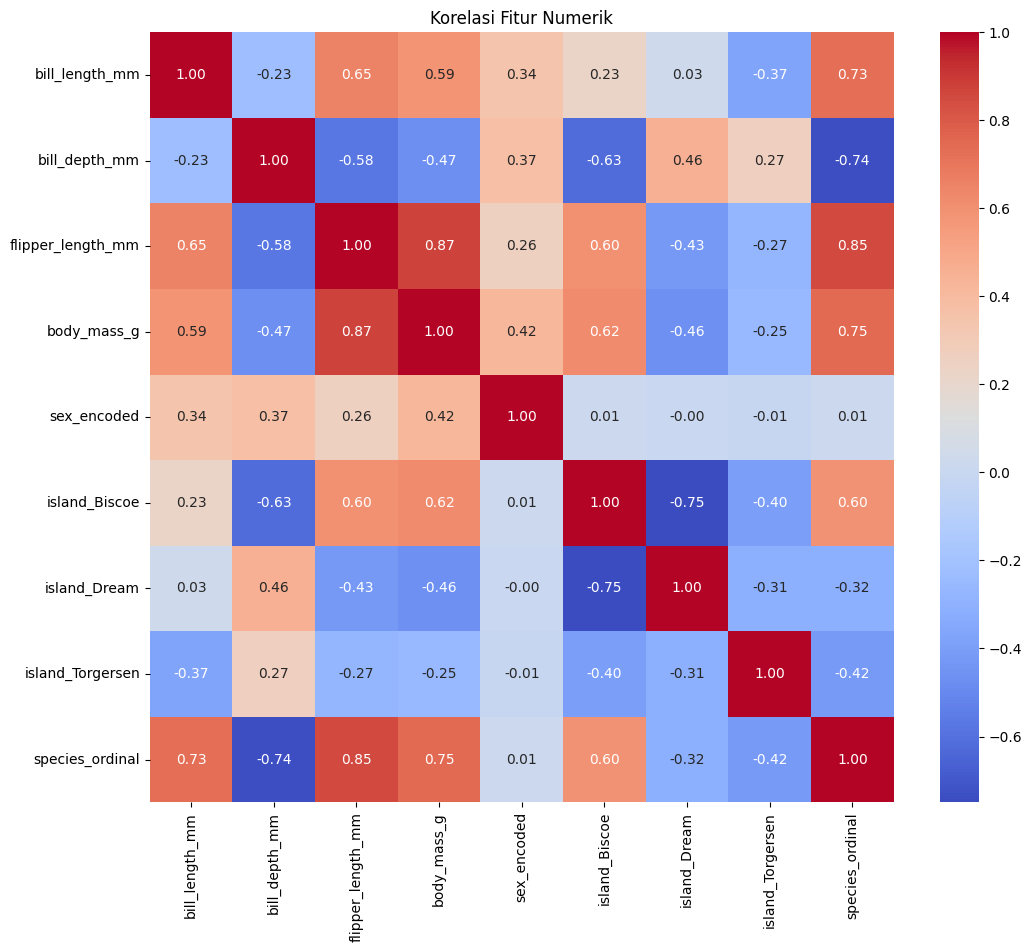

In [56]:
# Visualisasi korelasi menggunakan heatmap
plt.figure(figsize=(12, 10))

sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Korelasi Fitur Numerik")
plt.show()

### Cara membaca korelasi

Nilai korelasi berada dari **-1 sampai 1**.

- mendekati `1` -> hubungan positif kuat
- mendekati `-1` -> hubungan negatif kuat
- mendekati `0` -> hubungan linear lemah (tidak berkaitan/tidak berpola/acak banget)

Pada dataset ini, korelasi `flipper_length_mm` dan `body_mass_g` sekitar **0.87**, menunjukkan hubungan positif yang sangat kuat. Artinya, penguin dengan massa tubuh yang besar cenderung memiliki panjang sayap yang cenderung panjang juga

Hasil korelasi juga dapat membantu menemukan fitur yang sangat mirip/redundan.

## 8. Exploratory Data Analysis (EDA)

EDA dapat dilakukan secara:
- **Univariat** -> satu fitur
- **Bivariat** -> hubungan dua fitur
- **Agregasi** -> merangkum data berdasarkan kelompok

Tujuannya bukan sekadar membuat grafik, tetapi **menemukan insight yang dapat dijelaskan dengan data**.

### a. Analisis Univariat

Untuk data kategorikal, dapat menggunakan `value_counts()`.

In [34]:
print("Frekuensi Species:")
print(df["species"].value_counts())

print("\nFrekuensi Island:")
print(df["island"].value_counts())

print("\nFrekuensi Sex:")
print(df["sex"].value_counts())

Frekuensi Species:
species
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64

Frekuensi Island:
island
Biscoe       163
Dream        123
Torgersen     47
Name: count, dtype: int64

Frekuensi Sex:
sex
Male      168
Female    165
Name: count, dtype: int64


In [57]:
df[["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]].describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,333.000000,333.000000,333.000000,333.000000
mean,43.992793,17.164865,200.966967,4207.057057
std,5.468668,1.969235,14.015765,805.215802
min,32.100000,13.100000,172.000000,2700.000000
25%,39.500000,15.600000,190.000000,3550.000000
50%,44.500000,17.300000,197.000000,4050.000000
75%,48.600000,18.700000,213.000000,4775.000000
max,59.600000,21.500000,231.000000,6300.000000


### b. Analisis Bivariat dan Agregasi

Dapat menggunakan `groupby()` untuk membandingkan karakteristik antar kelompok berdasarkan mean, min, dan max-nya.

In [58]:
bivariat = df.groupby("species").agg({
    "bill_length_mm": ["mean", "min", "max"],
    "bill_depth_mm": ["mean", "min", "max"],
    "flipper_length_mm": ["mean", "min", "max"],
    "body_mass_g": ["mean", "min", "max"]
})

bivariat

bill_length_mm             bill_depth_mm              \
                    mean   min   max          mean   min   max   
species                                                          
Adelie         38.823973  32.1  46.0     18.347260  15.5  21.5   
Chinstrap      48.833824  40.9  58.0     18.420588  16.4  20.8   
Gentoo         47.568067  40.9  59.6     14.996639  13.1  17.3   

          flipper_length_mm                body_mass_g                  
                       mean    min    max         mean     min     max  
species                                                                 
Adelie           190.102740  172.0  210.0  3706.164384  2850.0  4775.0  
Chinstrap        195.823529  178.0  212.0  3733.088235  2700.0  4800.0  
Gentoo           217.235294  203.0  231.0  5092.436975  3950.0  6300.0

Selanjutnya bisa membuat analisis yang lebih spesifik dengan dua kolom pengelompokan.

In [69]:
# Rata-rata massa tubuh berdasarkan island dan species
multi_level_summary = (df.groupby(["island", "species"]).agg(body_mass_g_mean=("body_mass_g", "mean")))

multi_level_summary

body_mass_g_mean
island    species                    
Biscoe    Adelie          3709.659091
          Gentoo          5092.436975
Dream     Adelie          3701.363636
          Chinstrap       3733.088235
Torgersen Adelie          3708.510638

## 9. Visualisasi Distribusi

Jenis diagram dan fungsinya:

- **Histogram** -> melihat distribusi/frekuensi
- **KDE** -> melihat bentuk distribusi secara halus
- **Box Plot** -> melihat median, quartile, spread, dan outlier
- **Violin Plot** -> melihat bentuk distribusi dan membandingkan kelompok
- **Scatter Plot** -> melihat hubungan dua variabel numerik

### a. Histogram

Kita ingin melihat distribusi massa tubuh pinguin.

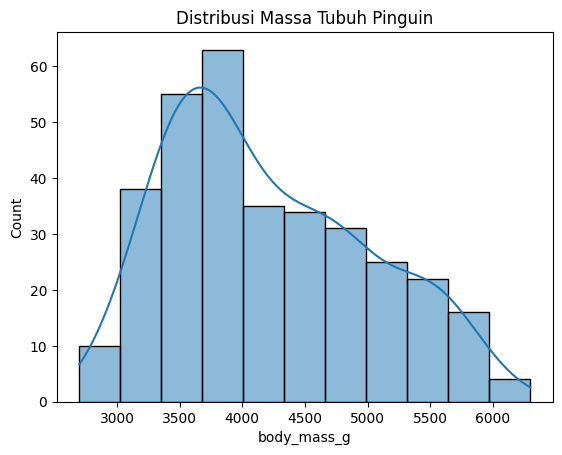

In [71]:
sns.histplot(data=df, x="body_mass_g", kde=True)

plt.title("Distribusi Massa Tubuh Pinguin")
plt.show()

Histogram membantu melihat bentuk distribusi.

`kde=True` menambahkan kurva KDE untuk membantu melihat bentuk distribusi secara lebih halus.

### b. Box Plot

Sekarang bandingkan panjang sirip antar spesies.

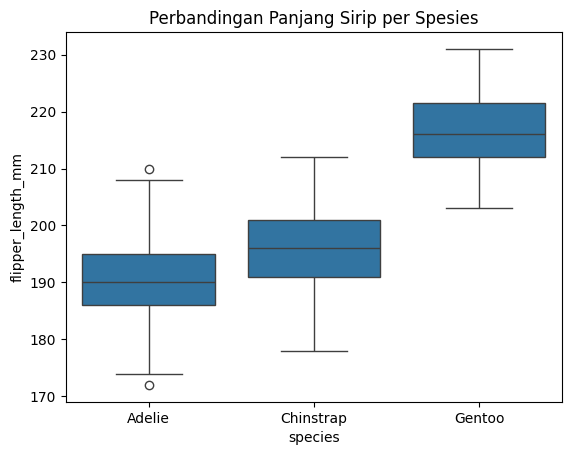

In [72]:
sns.boxplot(data=df, x="species", y="flipper_length_mm")

plt.title("Perbandingan Panjang Sirip per Spesies")
plt.show()

Box plot membantu melihat:
- median
- 50% data tengah (IQR)
- rentang data
- outlier

Plot ini dapat digunakan untuk membandingkan distribusi panjang sirip setiap species.

### c. Violin Plot

Violin plot akan menggabungkan informasi box plot dengan bentuk distribusi KDE.

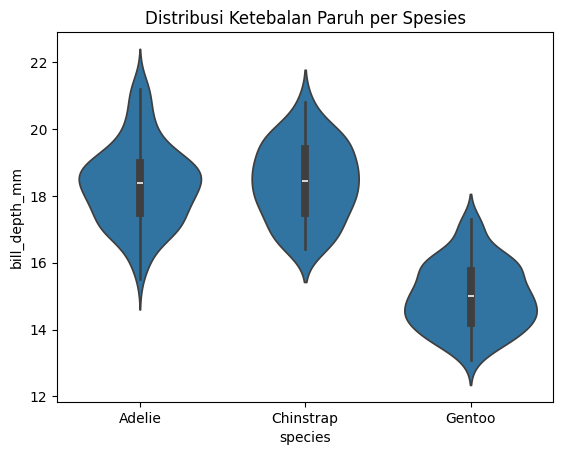

In [74]:
sns.violinplot(data=df, x="species", y="bill_depth_mm")

plt.title("Distribusi Ketebalan Paruh per Spesies")
plt.show()

Semakin lebar bagian violin pada suatu nilai, semakin banyak data yang terkonsentrasi di sekitar nilai tersebut.

### d. Scatter Plot

Validasi hubungan antara panjang sirip dan massa tubuh.

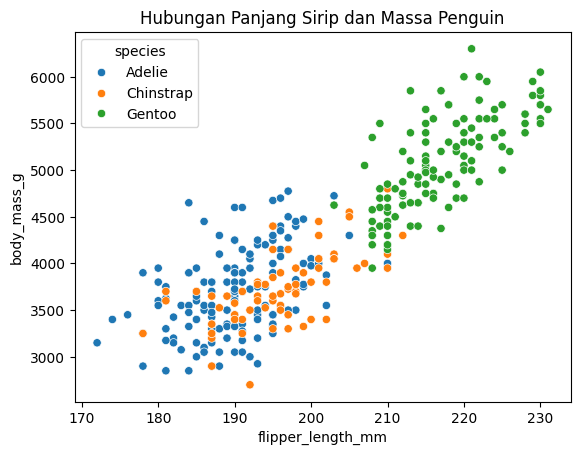

In [76]:
sns.scatterplot(data=df, x="flipper_length_mm", y="body_mass_g", hue="species")

plt.title("Hubungan Panjang Sirip dan Massa Penguin")
plt.show()

Jika titik-titik bergerak dari kiri bawah ke kanan atas, kecenderungan hubungannya adalah positif.

Parameter `hue="species"` membantu melihat apakah setiap species membentuk kelompok tertentu.

### e. Catplot

Untuk pertanyaan yang lebih kompleks, kita dapat membuat beberapa plot sekaligus.

Contoh:
**Bagaimana distribusi massa tubuh berdasarkan species dan sex di setiap island?**

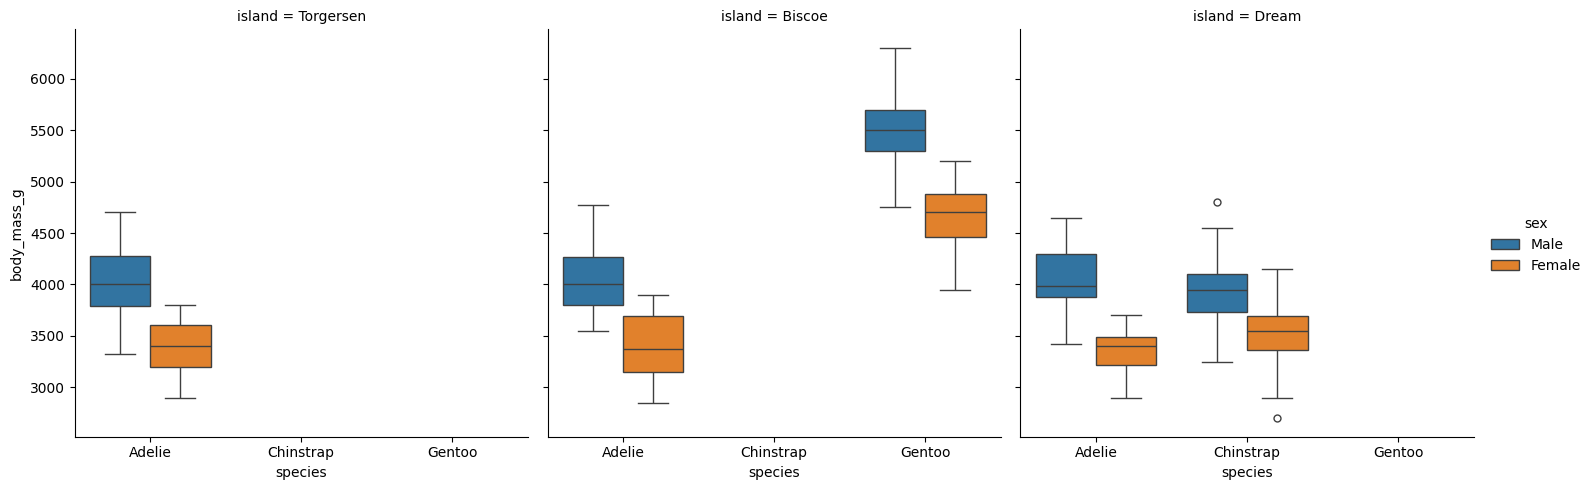

In [77]:
sns.catplot(data=df, x="species", y="body_mass_g", kind="box", col="island", hue="sex")

plt.show()

Dengan `col="island"`, grafik dibuat menjadi beberapa canvas berdasarkan pulau.

Dengan `hue="sex"`, kita dapat membandingkan laki-laki dan perempuan dalam setiap kelompok.

## 10. Simpan Data Hasil Feature Engineering

Setelah feature engineering dan cleaning selesai, dataset dapat disimpan untuk tahap berikutnya.

In [78]:
df.to_csv("penguins_feature_engineered.csv", index=False)

## Alur Materi Modul 3

```text
Dataset
   ↓
Cek Missing Value
   ↓
Encoding
   ↓
Binning
   ↓
Feature Selection
   ↓
  EDA
   ↓
Visualisasi
   ↓
Insight
```